# Proyecto - Implementación Fase 2
## Modelos DL
- Fabiola Contreras -22787
- María Villafuerte -22129

## Preparar el ambiente

In [42]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

from torchvision import transforms

from cnn_model import (
    QRDataset, QRCNN, train_one_epoch, evaluate, SEED
)

In [24]:
#  Dispositivo
device = (
    torch.device("cuda")  if torch.cuda.is_available()
    else torch.device("mps") if torch.backends.mps.is_available()
    else torch.device("cpu")
)
print(f"Dispositivo: {device}")

Dispositivo: cuda


In [25]:
# Datos
META_CSV = "data_procesada/qr_full_dataset.csv"

# Entrenamiento
EPOCHS   = 30
BATCH    = 64
LR       = 1e-3
DROPOUT  = 0.4
PATIENCE = 7

# Salida
OUT_DIR = Path("outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)


## Cargar datos

In [26]:
train_df = pd.read_csv("data_procesada/train.csv")
val_df   = pd.read_csv("data_procesada/val.csv")
test_df  = pd.read_csv("data_procesada/test.csv")

for df in [train_df, val_df, test_df]:
    df["filepath"] = df["filepath"].str.replace("\\", "/", regex=False)

train_paths = train_df["filepath"].tolist()
train_labels = train_df["label"].tolist()

val_paths = val_df["filepath"].tolist()
val_labels = val_df["label"].tolist()

test_paths = test_df["filepath"].tolist()
test_labels = test_df["label"].tolist()

print(len(train_paths), len(val_paths), len(test_paths))

140000 30000 30000


In [27]:
import os

def filter_existing(paths, labels):
    pairs = [(p, l) for p, l in zip(paths, labels) if os.path.exists(p)]
    return map(list, zip(*pairs))

train_paths, train_labels = filter_existing(train_paths, train_labels)
val_paths,   val_labels   = filter_existing(val_paths,   val_labels)
test_paths,  test_labels  = filter_existing(test_paths,  test_labels)

print(len(train_paths), len(val_paths), len(test_paths))

30510 6671 6517


In [28]:
aug = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(10),
])

ds_train = QRDataset(train_paths, train_labels, transform=aug)
ds_val   = QRDataset(val_paths, val_labels)
ds_test  = QRDataset(test_paths, test_labels)

print(f"Train: {len(ds_train)} | Val: {len(ds_val)} | Test: {len(ds_test)}")

Train: 30510 | Val: 6671 | Test: 6517


In [29]:
kw = dict(num_workers=4, pin_memory=(device.type == "cuda"))

train_loader = DataLoader(ds_train, batch_size=BATCH, shuffle=True,  **kw)
val_loader   = DataLoader(ds_val,   batch_size=BATCH, shuffle=False, **kw)
test_loader  = DataLoader(ds_test,  batch_size=BATCH, shuffle=False, **kw)

## Modelo CNN

In [13]:
model = QRCNN(dropout=DROPOUT).to(device)

print(f"Parámetros: {sum(p.numel() for p in model.parameters() if p.requires_grad)}")

Parámetros: 3142242


### Entrenamiento

In [26]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

best_val_loss = float("inf")
patience_cnt  = 0
history       = []

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    vl_loss, vl_acc, vl_auc, _, _ = evaluate(model, val_loader, criterion, device)

    scheduler.step()

    history.append({
        "epoch": epoch,
        "train_loss": tr_loss,
        "train_acc": tr_acc,
        "val_loss": vl_loss,
        "val_acc": vl_acc,
        "val_auc": vl_auc
    })

    print(epoch, tr_loss, vl_loss)

    if vl_loss < best_val_loss:
        best_val_loss = vl_loss
        patience_cnt = 0
        torch.save(model.state_dict(), OUT_DIR / "best_model.pt")
    else:
        patience_cnt += 1
        if patience_cnt >= PATIENCE:
            print(f"Early stopping en época {epoch}")
            break

1 0.16751428915304797 0.12951908467213313


Training:   0%|          | 0/2188 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


2 0.0515563755363492 0.02320835354673521


Training:   0%|          | 0/2188 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


3 0.030588803193033007 0.016022321930919618


...

28 0.0003209259784442603 0.0006379589542421165


Training:   0%|          | 0/2188 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


29 0.00032728928005123966 0.0006688574807630937


Training:   0%|          | 0/2188 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
                                                                                      

30 0.0004504731735452434 0.0006763761915978359


### Evaluación

In [37]:
model.load_state_dict(torch.load(OUT_DIR / "best_model.pt", map_location=device))

te_loss, te_acc, te_auc, preds, true, probs = evaluate(model, test_loader, criterion, device)

Evaluating:   0%|          | 0/469 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [43]:
print(f"Test Loss: {te_loss}")
print(f"Test Acc: {te_acc}")
print(f"Test AUC: {te_auc}")

Test Loss: 0.0006943410682397802
Test Acc: 0.9998666666666667
Test AUC: 0.9999998444444445


In [39]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

acc  = accuracy_score(true, preds)
prec = precision_score(true, preds)
rec  = recall_score(true, preds)
f1   = f1_score(true, preds)

print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1 Score : {f1:.4f}")

Accuracy : 0.9999
Precision: 0.9998
Recall   : 0.9999
F1 Score : 0.9999


In [44]:
print(classification_report(true, preds, target_names=["normal", "malware"]))

              precision    recall  f1-score   support

      normal       1.00      1.00      1.00     15000
     malware       1.00      1.00      1.00     15000

    accuracy                           1.00     30000
   macro avg       1.00      1.00      1.00     30000
weighted avg       1.00      1.00      1.00     30000



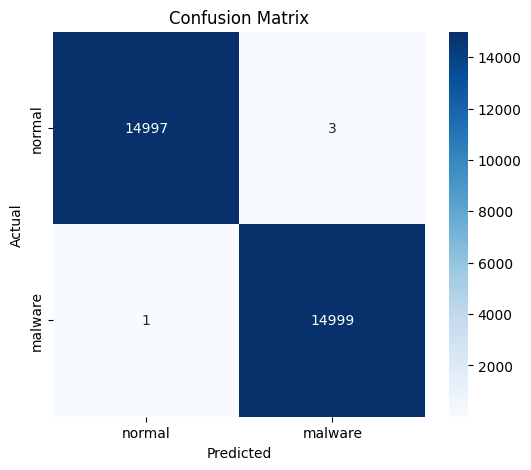

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(true, preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["normal", "malware"],
            yticklabels=["normal", "malware"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

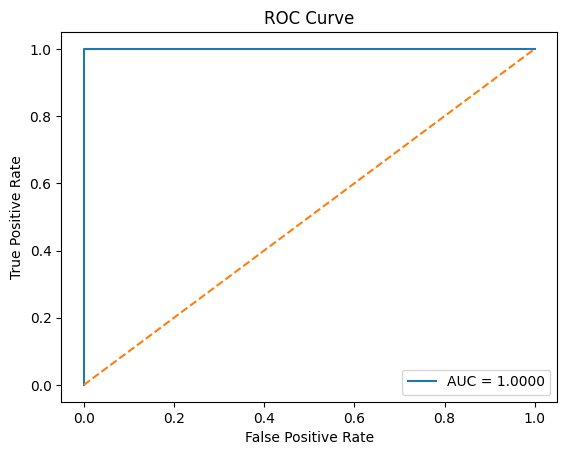

In [41]:
from sklearn.metrics import roc_curve, auc

# Asumiendo que tienes probabilidades en `probs`
fpr, tpr, _ = roc_curve(true, probs)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

### Guardar resultados

In [ ]:
pd.DataFrame(history).to_csv(OUT_DIR / "training_cnn_history.csv", index=False)

with open(OUT_DIR / "test_metrics.json", "w") as f:
    json.dump({
        "test_loss": te_loss,
        "test_acc": te_acc,
        "test_auc": te_auc
    }, f, indent=2)

print(f"Artefactos guardados en {OUT_DIR}")

In [ ]:
df_preds = pd.DataFrame({
    "true": true,
    "pred": preds,
    "prob_malware": probs
})

df_preds.to_csv(OUT_DIR / "test_predictions.csv", index=False)

## Modelo ViT (Vision Transformer)

### Configuración e instalación

In [30]:
# timm ya viene instalado en Colab; si no: 
import timm
print(f"timm version: {timm.__version__}")

timm version: 1.0.26


In [31]:
model = QRCNN(dropout=DROPOUT).to(device)

print(f"Parámetros: {sum(p.numel() for p in model.parameters() if p.requires_grad)}")
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)


Parámetros: 3142242


In [32]:
LR_VIT        = 1e-4   # LR menor para fine-tuning de pesos preentrenados
EPOCHS_VIT    = 30
FREEZE_LAYERS = 6      # congelar primeros 6 bloques transformer

vit_model = timm.create_model(
    'vit_tiny_patch16_224',
    pretrained=True,
    in_chans=1,
    num_classes=2,
    img_size=128,   # 128/16=8 → 8×8=64 patches
)
vit_model = vit_model.to(device)

for block in list(vit_model.blocks.children())[:FREEZE_LAYERS]:
    for param in block.parameters():
        param.requires_grad = False

total_params     = sum(p.numel() for p in vit_model.parameters())
trainable_params = sum(p.numel() for p in vit_model.parameters() if p.requires_grad)
print(f"Parámetros totales    : {total_params:,}")
print(f"Parámetros entrenables: {trainable_params:,}")

Parámetros totales    : 5,401,154
Parámetros entrenables: 2,731,970


### Entrenamiento

In [33]:
optimizer_vit = optim.AdamW(
    filter(lambda p: p.requires_grad, vit_model.parameters()),
    lr=LR_VIT, weight_decay=1e-4
)
scheduler_vit = optim.lr_scheduler.CosineAnnealingLR(optimizer_vit, T_max=EPOCHS_VIT)

best_val_loss_vit = float("inf")
patience_cnt_vit  = 0
history_vit       = []

for epoch in range(1, EPOCHS_VIT + 1):
    tr_loss, tr_acc = train_one_epoch(
        vit_model, train_loader, criterion, optimizer_vit, device
    )
    vl_loss, vl_acc, vl_auc, _, _ = evaluate(
        vit_model, val_loader, criterion, device
    )
    scheduler_vit.step()

    history_vit.append({
        "epoch": epoch, "train_loss": tr_loss,
        "train_acc": tr_acc, "val_loss": vl_loss,
        "val_acc": vl_acc, "val_auc": vl_auc
    })
    print(epoch, tr_loss, vl_loss)

    if vl_loss < best_val_loss_vit:
        best_val_loss_vit = vl_loss
        patience_cnt_vit  = 0
        torch.save(vit_model.state_dict(), OUT_DIR / "best_vit_model.pt")
    else:
        patience_cnt_vit += 1
        if patience_cnt_vit >= PATIENCE:
            print(f"Early stopping en época {epoch}")
            break

1 0.5977082804162868 0.5092660133546661


2 0.39148777125898404 0.2692136989596222


3 0.30675198380105495 0.21183076457111683


4 0.24432897074267107 0.20832532886407343


5 0.20198922519682275 0.136672160839359


...

26 0.022610651687128266 0.021005687844960333


27 0.024469484039956246 0.020326543944686644


28 0.02304079745423326 0.020398959549658504


29 0.020695374518881975 0.020437753885948682


30 0.021578048101389156 0.02003345259820858


### Evaluación

In [45]:
from cnn_model import QRDataset
ds_test_new  = QRDataset(test_paths, test_labels)
ds_val_new   = QRDataset(val_paths, val_labels)
test_loader  = DataLoader(ds_test_new, batch_size=BATCH, shuffle=False, num_workers=0)
val_loader   = DataLoader(ds_val_new,  batch_size=BATCH, shuffle=False, num_workers=0)


In [46]:
vit_model.load_state_dict(torch.load(OUT_DIR / "best_vit_model.pt", map_location=device))

vit_loss, vit_acc, vit_auc, vit_preds, vit_true, vit_probs = evaluate(
    vit_model, test_loader, criterion, device
)


In [47]:
print(f"Test Loss: {vit_loss}")
print(f"Test Acc : {vit_acc}")
print(f"Test AUC : {vit_auc}")

Test Loss: 0.015833274616668502
Test Acc : 0.9938622065367501
Test AUC : 0.9998619204213293


In [49]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc, confusion_matrix, classification_report

In [50]:
vit_acc_sk = accuracy_score(vit_true, vit_preds)
vit_prec   = precision_score(vit_true, vit_preds)
vit_rec    = recall_score(vit_true, vit_preds)
vit_f1     = f1_score(vit_true, vit_preds)

print(f"Accuracy : {vit_acc_sk:.4f}")
print(f"Precision: {vit_prec:.4f}")
print(f"Recall   : {vit_rec:.4f}")
print(f"F1 Score : {vit_f1:.4f}")

Accuracy : 0.9939
Precision: 0.9911
Recall   : 0.9966
F1 Score : 0.9938


In [51]:
print(classification_report(vit_true, vit_preds, target_names=["normal", "malware"]))

              precision    recall  f1-score   support

      normal       1.00      0.99      0.99      3286
     malware       0.99      1.00      0.99      3231

    accuracy                           0.99      6517
   macro avg       0.99      0.99      0.99      6517
weighted avg       0.99      0.99      0.99      6517



In [53]:
import matplotlib.pyplot as plt
import seaborn as sns


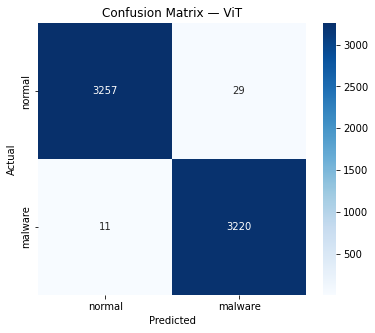

In [54]:
cm_vit = confusion_matrix(vit_true, vit_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_vit, annot=True, fmt="d", cmap="Blues",
            xticklabels=["normal", "malware"],
            yticklabels=["normal", "malware"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — ViT")
plt.show()

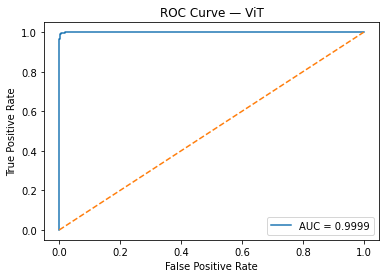

In [ ]:
from sklearn.metrics import roc_curve, auc

fpr_vit, tpr_vit, _ = roc_curve(vit_true, vit_probs)
roc_auc_vit = auc(fpr_vit, tpr_vit)

plt.figure()
plt.plot(fpr_vit, tpr_vit, label=f"AUC = {roc_auc_vit:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — ViT")
plt.legend()
plt.show()

### Guardar resultados

In [ ]:
pd.DataFrame(history_vit).to_csv(OUT_DIR / "training_vit_history.csv", index=False)

with open(OUT_DIR / "test_metrics_vit.json", "w") as f:
    json.dump({"test_loss": vit_loss, "test_acc": vit_acc, "test_auc": vit_auc}, f, indent=2)

pd.DataFrame({
    "true": vit_true,
    "pred": vit_preds,
    "prob_malware": vit_probs
}).to_csv(OUT_DIR / "test_predictions_vit.csv", index=False)

print(f"Artefactos guardados en {OUT_DIR}")

Artefactos guardados en outputs


## Comparación de Modelos

In [ ]:
with open(OUT_DIR / "test_metrics.json") as f:
    cnn_m = json.load(f)
with open(OUT_DIR / "test_metrics_vit.json") as f:
    vit_m = json.load(f)
with open(OUT_DIR / "test_metrics_hybrid.json") as f:
    hyb_m = json.load(f)

cnn_df = pd.read_csv(OUT_DIR / "test_predictions.csv")
vit_df = pd.read_csv(OUT_DIR / "test_predictions_vit.csv")
hyb_df = pd.read_csv(OUT_DIR / "test_predictions_hybrid.csv")

def make_row(name, m, df):
    t, p = df["true"].tolist(), df["pred"].tolist()
    return {
        "Modelo":    name,
        "Accuracy":  m["test_acc"],
        "Precision": precision_score(t, p),
        "Recall":    recall_score(t, p),
        "F1":        f1_score(t, p),
        "AUC-ROC":   m["test_auc"],
        "Test Loss": m["test_loss"],
    }

comp = pd.DataFrame([
    make_row("CNN (QRCNN)",       cnn_m, cnn_df),
    make_row("ViT (vit_tiny)",    vit_m, vit_df),
    make_row("Hibrido CNN+Stats", hyb_m, hyb_df),
]).set_index("Modelo")

print(comp.to_string(float_format=lambda x: f"{x:.6f}"))

In [ ]:
metrics_cols = ["Accuracy", "Precision", "Recall", "F1", "AUC-ROC"]
colors = ["#1565C0", "#E64A19", "#2E7D32"]

fig, axes = plt.subplots(1, 5, figsize=(18, 5))

for ax, metric in zip(axes, metrics_cols):
    vals   = comp[metric].values
    models = comp.index.tolist()
    bars   = ax.bar(models, vals, color=colors, edgecolor="white", width=0.5)
    ax.set_ylim(max(0, min(vals) - 0.005), 1.005)
    ax.set_title(metric, fontsize=11)
    ax.tick_params(axis="x", rotation=15)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.0005,
                f"{v:.4f}", ha="center", va="bottom", fontsize=8)

plt.suptitle("Comparacion — Test Set (30K imagenes)", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(OUT_DIR / "model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Grafico guardado en outputs/model_comparison.png")

In [ ]:
fig, ax = plt.subplots(figsize=(7, 6))

for name, df, color in [
    ("CNN (QRCNN)",       cnn_df, "#1565C0"),
    ("ViT (vit_tiny)",    vit_df, "#E64A19"),
    ("Hibrido CNN+Stats", hyb_df, "#2E7D32"),
]:
    fpr_i, tpr_i, _ = roc_curve(df["true"], df["prob_malware"])
    ax.plot(fpr_i, tpr_i, color=color, label=f"{name} (AUC={auc(fpr_i, tpr_i):.4f})")

ax.plot([0, 1], [0, 1], "k--", alpha=0.4)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves — Comparacion de Modelos")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig(OUT_DIR / "roc_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Grafico guardado en outputs/roc_comparison.png")